In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.ingredients_analysis import plot_ingrs_daily_consumption
from src.analysis.metrics import calculate_rmse, calculate_mape, calculate_mae
from src.modeling.feature_engineering import *
from src.modeling.model import *
from src.modeling.evaluation import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

In [2]:
# Restaurant data with the 25 most frequent ingredients
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

numerical_features = daily_consumption_df.columns
print(numerical_features)

,Salt,Garlic,Clove,Paprika
Date,,,,
2019-01-01,162.974727,19.849773,0.125728,2.441247
2019-01-02,99.851043,13.459318,0.070579,1.808771
2019-01-03,119.860452,15.462596,0.055736,2.481908
2019-01-04,97.104337,13.284490,0.052449,1.406736
2019-01-05,198.989110,27.495572,0.149708,3.414856
...,...,...,...,...
2019-06-26,114.141431,14.064159,0.061994,2.004435
2019-06-27,213.521591,31.728243,0.129388,3.366290
2019-06-28,186.391889,25.140486,0.114119,2.857067


Index(['Salt', 'Garlic', 'Clove', 'Paprika'], dtype='object')


##### Scale Numerical Features

In [3]:
# Applying feature scaling to numerical features
scaler, scaled_numerical_df = apply_scale_to_numerical_features(daily_consumption_df, numerical_features)

daily_consumption_scaled_df = scaled_numerical_df
display(daily_consumption_scaled_df)

,Salt,Garlic,Clove,Paprika
Date,,,,
2019-01-01,-0.323275,-0.403792,-0.035040,-0.410249
2019-01-02,-0.842245,-0.801374,-0.703336,-0.709197
2019-01-03,-0.677738,-0.676740,-0.883203,-0.391030
2019-01-04,-0.864827,-0.812251,-0.923043,-0.899225
2019-01-05,-0.027183,0.071891,0.255559,0.049941
...,...,...,...,...
2019-06-26,-0.724757,-0.763744,-0.807378,-0.616714
2019-06-27,0.092296,0.335227,0.009315,0.026985
2019-06-28,-0.130751,-0.074631,-0.175712,-0.213706


##### Create Lag Features

In [4]:
window = 5
feature_columns = numerical_features
target_columns = numerical_features
(time_sequences_df, X, y) = generate_lag_features(daily_consumption_scaled_df, feature_columns, target_columns , window)
print("Time-Shifted Features: ")
display(time_sequences_df)
print(f"X numpy: {X.shape}, Dimensions: {X.ndim}")
print(f"y numpy: {y.shape}, Dimensions: {y.ndim}", '\n')

Time-Shifted Features: 


,Salt,Garlic,Clove,Paprika,Salt(t-1),Salt(t-2),Salt(t-3),Salt(t-4),Salt(t-5),Garlic(t-1),...,Clove(t-1),Clove(t-2),Clove(t-3),Clove(t-4),Clove(t-5),Paprika(t-1),Paprika(t-2),Paprika(t-3),Paprika(t-4),Paprika(t-5)
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-06,0.499909,0.578827,0.136228,-0.067036,-0.027183,-0.864827,-0.677738,-0.842245,-0.323275,0.071891,...,0.255559,-0.923043,-0.883203,-0.703336,-0.035040,0.049941,-0.899225,-0.391030,-0.709197,-0.410249
2019-01-07,1.657008,1.828042,1.322394,1.705055,0.499909,-0.027183,-0.864827,-0.677738,-0.842245,0.578827,...,0.136228,0.255559,-0.923043,-0.883203,-0.703336,-0.067036,0.049941,-0.899225,-0.391030,-0.709197
2019-01-08,0.072880,0.015589,0.478833,-0.191085,1.657008,0.499909,-0.027183,-0.864827,-0.677738,1.828042,...,1.322394,0.136228,0.255559,-0.923043,-0.883203,1.705055,-0.067036,0.049941,-0.899225,-0.391030
2019-01-09,-1.226161,-1.214641,-1.102895,-1.200292,0.072880,1.657008,0.499909,-0.027183,-0.864827,0.015589,...,0.478833,1.322394,0.136228,0.255559,-0.923043,-0.191085,1.705055,-0.067036,0.049941,-0.899225
2019-01-10,-0.624111,-0.632855,-0.706730,-0.873330,-1.226161,0.072880,1.657008,0.499909,-0.027183,-1.214641,...,-1.102895,0.478833,1.322394,0.136228,0.255559,-1.200292,-0.191085,1.705055,-0.067036,0.049941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-26,-0.724757,-0.763744,-0.807378,-0.616714,0.331407,2.085367,1.582264,-0.368101,-0.820482,0.517630,...,0.328486,1.005716,1.498324,-0.248491,-0.901541,0.665932,1.550236,1.145279,-0.444785,-0.703963
2019-06-27,0.092296,0.335227,0.009315,0.026985,-0.724757,0.331407,2.085367,1.582264,-0.368101,-0.763744,...,-0.807378,0.328486,1.005716,1.498324,-0.248491,-0.616714,0.665932,1.550236,1.145279,-0.444785
2019-06-28,-0.130751,-0.074631,-0.175712,-0.213706,0.092296,-0.724757,0.331407,2.085367,1.582264,0.335227,...,0.009315,-0.807378,0.328486,1.005716,1.498324,0.026985,-0.616714,0.665932,1.550236,1.145279


X numpy: (176, 5, 4), Dimensions: 3
y numpy: (176, 4), Dimensions: 2 



Number of folds:  3
Number of timespteps:  176 

Fold 1/3
Train set timesteps: 1 to 44
Test set timesteps: 45 to 88
LSTM modeling and training ...
Early stopping at epoch 43, no improvement in 30 consecutive epochs.
Training completed. Best epoch: 13, Best Validation Loss: 0.5544995864232382, RMSE: 24.120391845703125

Fold 2/3
Train set timesteps: 1 to 88
Test set timesteps: 89 to 132
LSTM modeling and training ...
Early stopping at epoch 95, no improvement in 30 consecutive epochs.
Training completed. Best epoch: 65, Best Validation Loss: 0.35765454173088074, RMSE: 21.83130645751953

Fold 3/3
Train set timesteps: 1 to 132
Test set timesteps: 133 to 176
LSTM modeling and training ...
Early stopping at epoch 68, no improvement in 30 consecutive epochs.
Training completed. Best epoch: 38, Best Validation Loss: 0.38222890098889667, RMSE: 20.474302291870117


CROSS-VALIDATION RESULTS:
Average RMSE across 3 folds: 22.142000198364258
Fold 1 - Best Validation Loss: 0.5544995864232382, Best RM

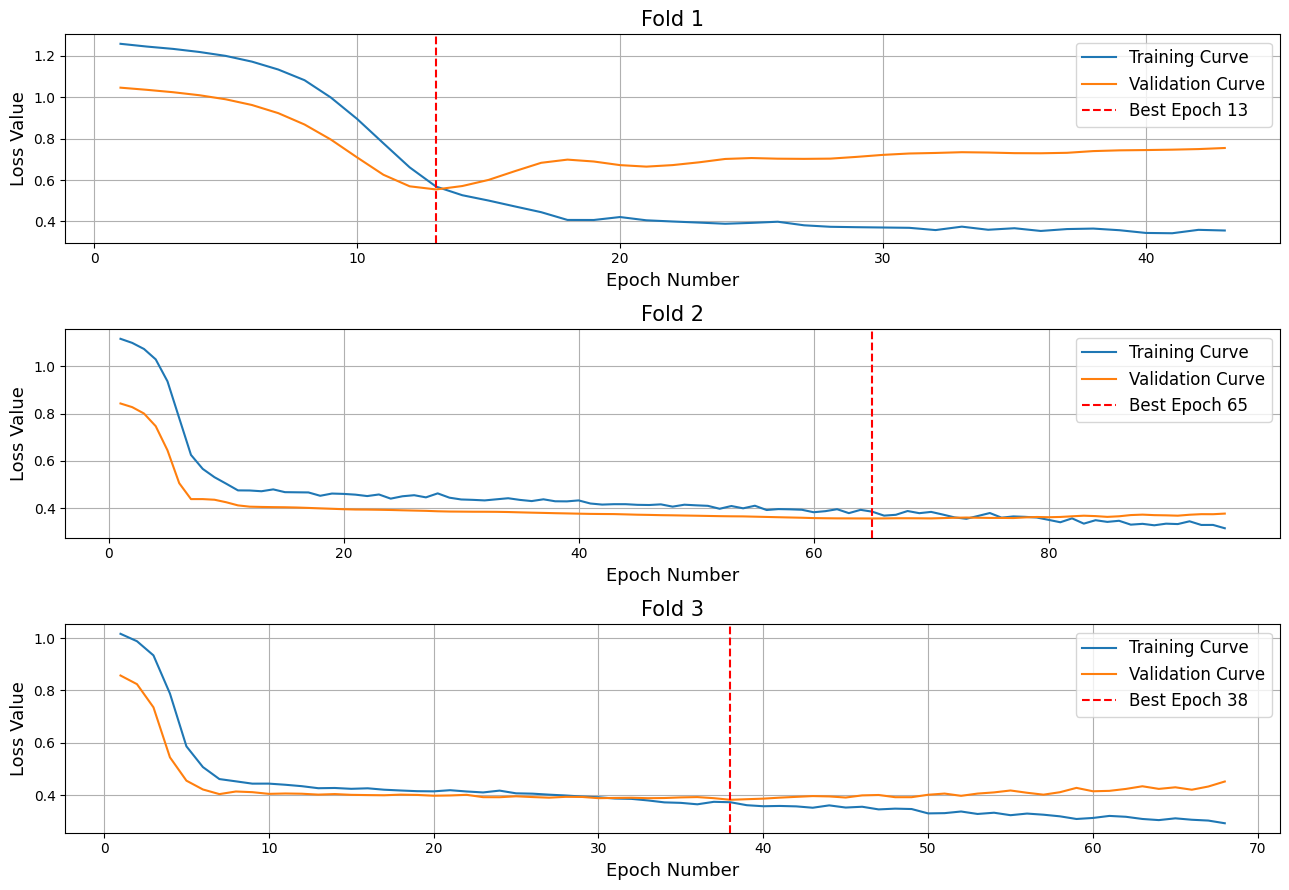

In [5]:
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.model_selection import TimeSeriesSplit

# Hyperparameters
batch_size = 16
features_number = len(feature_columns)
hidden_size = 50
num_stack_layers = 2
output_size = len(target_columns)
learning_rate = 0.001
num_epochs = 150

patience = 30  # For early stopping

# Rolling Window CV with n folds
n_folds = 3  # You can increase this if needed
tss = TimeSeriesSplit(n_splits=n_folds)
print("Number of folds: ", n_folds)
print("Number of timespteps: ", len(X), "\n")

# For storing the results of each fold
fold_results = []
# For storing RMSE values
fold_rmse_values = []

for fold_idx, (train_index, test_index) in enumerate(tss.split(X)):
    
    # Print the current fold and the training/testing time steps
    print(f"Fold {fold_idx+1}/{n_folds}")

    # Create training and test datasets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Print the start and end timesteps for train and test sets
    print(f"Train set timesteps: {train_index[0]+1} to {train_index[-1]+1}")
    print(f"Test set timesteps: {test_index[0]+1} to {test_index[-1]+1}")

    # Convert to PyTorch tensors
    X_train, X_test = torch.tensor(X_train).float(), torch.tensor(X_test).float()
    y_train, y_test = torch.tensor(y_train).float(), torch.tensor(y_test).float()

    # Create DataLoader for this fold
    train_dataset = TimeSeriesDataset(X_train, y_train)
    test_dataset = TimeSeriesDataset(X_test, y_test)
    
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize the model, loss function, and optimizer for this fold
    model = LSTM(features_number, hidden_size, num_stack_layers, output_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    loss_function = torch.nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Early stopping variables
    best_val_loss = float('inf') 
    best_epoch = 0
    epochs_no_improve = 0  # Counts epochs without improvement

    best_train_pred, train_actuals = [], []
    best_test_pred, test_actuals = [], []

    train_loss_hist =[]
    test_loss_hist =[]

    # Training and evaluation
    print("LSTM modeling and training ...")
    for epoch in range(num_epochs):
        # Training phase
        train_loss, train_predictions, train_actuals = train_loop(train_dataloader, model, loss_function, optimizer, device)
        train_loss_hist.append(train_loss)

        # Validation phase
        val_loss, test_predictions, test_actuals = test_loop(test_dataloader, model, loss_function, device)
        test_loss_hist.append(val_loss)

        #print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}')

        # Update the best_val_loss
        if val_loss < best_val_loss: 
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            #print(f"Best validation loss updated to {best_val_loss} at epoch {best_epoch}\n")

            # To plot pred vs actuals later for each fold 
            best_train_pred = train_predictions
            train_actuals = train_actuals
            best_test_pred = test_predictions
            test_actuals = test_actuals
        else:
            epochs_no_improve += 1
        
        # Early stopping: Stop if no improvement after 'patience' epochs
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}, no improvement in {patience} consecutive epochs.")
            break

    # Denormalize data
    best_test_pred_den, test_actuals_den = apply_denormalization(scaler, best_test_pred, test_actuals)

    # Calculate RMSE for this fold
    rmse = calculate_rmse(np.array(test_actuals_den), np.array(best_test_pred_den))
    fold_rmse_values.append(rmse)

    # Store the results of this fold
    fold_results.append({
        'fold': fold_idx + 1,
        'start_timestep': test_index[0],
        'end_timestep': test_index[-1],
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_rmse': rmse,
        'train_loss_hist': train_loss_hist,
        'test_loss_hist': test_loss_hist,
        'best_test_pred': best_test_pred_den,   # denormalized
        'test_actuals': test_actuals_den,       # denormalized
    })

    print(f"Training completed. Best epoch: {best_epoch}, Best Validation Loss: {best_val_loss}, RMSE: {rmse}\n")


print("\nCROSS-VALIDATION RESULTS:")

# Calculate average RMSE across all folds
average_rmse = np.mean(fold_rmse_values)
print(f"Average RMSE across {n_folds} folds: {average_rmse}")

# Plotting all results in a single column figure
fig, axes = plt.subplots(n_folds, 1, figsize=(13, 3 * n_folds))
#fig.suptitle('Training and Validation Loss Over Epochs for Each Fold', fontsize=16)

for fold_idx, fold_result in enumerate(fold_results):
    fold_id = fold_result['fold']
    best_val_loss = fold_result['best_val_loss']
    train_loss_hist = fold_result['train_loss_hist']
    test_loss_hist = fold_result['test_loss_hist']
    best_epoch = fold_result['best_epoch']
    rmse = fold_result['best_rmse']

    print(f"Fold {fold_id} - Best Validation Loss: {best_val_loss}, Best RMSE: {rmse}")

    epochs_range = range(1, len(train_loss_hist) + 1)
    ax = axes[fold_idx]
    ax.plot(epochs_range, train_loss_hist, label='Training Curve')
    ax.plot(epochs_range, test_loss_hist, label='Validation Curve')
    ax.axvline(best_epoch, linestyle='--', color='red', label=f'Best Epoch {best_epoch}')
    ax.set_title(f'Fold {fold_idx + 1}', fontsize=15)  # Increase title font size
    ax.set_xlabel('Epoch Number', fontsize=13)  # Increase x-axis label font size
    ax.set_ylabel('Loss Value', fontsize=13)  # Increase y-axis label font size
    ax.legend(fontsize=12)  # Increase legend font size
    ax.grid(True)

plt.tight_layout()
plt.show()

Best fold is Fold 3 with RMSE: 20.474302291870117

Salt RMSE:  70.27243
Salt MAPE:  34.617358446121216
Salt MAE:  56.93362

Garlic RMSE:  10.172355
Garlic MAPE:  34.07645523548126
Garlic MAE:  7.785675

Clove RMSE:  0.054191463
Clove MAPE:  43.1123286485672
Clove MAE:  0.040916502

Paprika RMSE:  1.3982418
Paprika MAPE:  40.218913555145264
Paprika MAE:  1.0182064


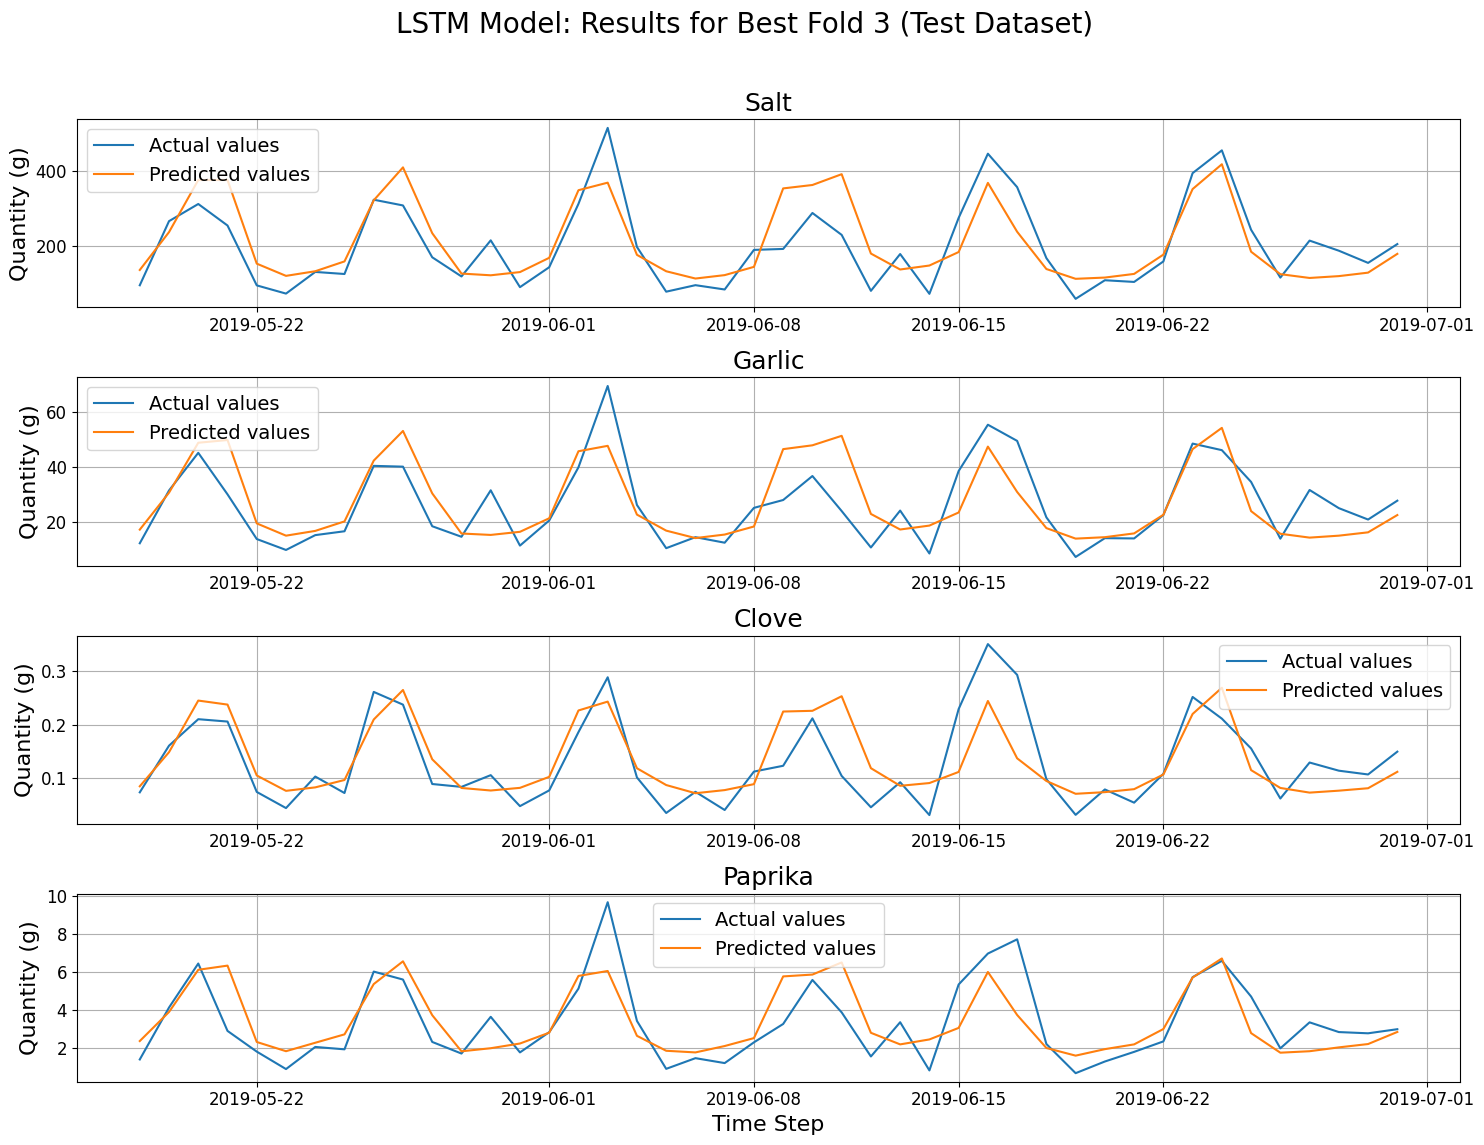

In [6]:
# Find the fold with the best validation loss
best_fold_result = min(fold_results, key=lambda x: x['best_rmse'])
best_fold_idx = best_fold_result['fold'] - 1  # fold index starts from 0

# Print the fold with the best result
print(f"Best fold is Fold {best_fold_result['fold']} with RMSE: {best_fold_result['best_rmse']}")

# Start and end timesteps for the best fold
start_timestep = fold_results[best_fold_idx]['start_timestep']
end_timestep = fold_results[best_fold_idx]['end_timestep']

best_test_pred = np.array(fold_results[best_fold_idx]['best_test_pred'])  # predictions from best fold
test_actuals = np.array(fold_results[best_fold_idx]['test_actuals'])  # actual values from the best fold

# Prepare time steps for the test set of the best fold
time_steps_test = time_sequences_df.index[start_timestep:end_timestep+1]

# Plotting the predicted vs actual values for each output
fig, axes = plt.subplots(output_size, 1, figsize=(15, 3 * output_size))
fig.suptitle(f'LSTM Model: Results for Best Fold {best_fold_result["fold"]} (Test Dataset)', fontsize=20)  # Increase the main title font size

# Create a list to store the individual DataFrames
results_list = []

for idx, ingredient in enumerate(target_columns):
    print()
    ingr_rmse = calculate_rmse(test_actuals[:, idx], best_test_pred[:, idx])
    print(f'{ingredient} RMSE: ', ingr_rmse)
    ingr_MAPE = calculate_mape(test_actuals[:, idx], best_test_pred[:, idx])
    print(f'{ingredient} MAPE: ', ingr_MAPE)
    ingr_mae = calculate_mae(test_actuals[:, idx], best_test_pred[:, idx])  # Calculate MAE
    print(f'{ingredient} MAE: ', ingr_mae)  # Print MAE

    # Testing data
    ingr_test_pred = best_test_pred[:, idx].reshape(-1, 1)
    ingr_test_actuals = test_actuals[:, idx].reshape(-1, 1)

    # Plot the results
    ax = axes[idx]
    ax.plot(time_steps_test, ingr_test_actuals, label='Actual values')
    ax.plot(time_steps_test, ingr_test_pred, label='Predicted values')
    
    ax.set_title(f'{ingredient}', fontsize=18)  # Increase title font size for each subplot
    # Set x-axis label only for the last subplot
    if idx == output_size - 1:
        ax.set_xlabel('Time Step', fontsize=16)  # Increase x-axis label font size
    ax.set_ylabel('Quantity (g)', fontsize=16)  # Increase y-axis label font size
    
    ax.legend(fontsize=14)  # Increase legend font size
    ax.grid(True)
    
    # Increase tick label font size
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])  # Adjust layout to make space for the suptitle
plt.show()


#### Medium-Term Forecast (Next 3 Days of July 2019)

- Time Serie Dataset: 1 January - 30 June

- Time Serie Dataset with Lag: (1 January + window) - 30 June, eg. if W=4 => 5 January - 30 June

- Existing Forecast Dates = 30 days, represents the forecast consumption in existing dates (to compare)

- Future Forecast Dates = 3 days , represents the forecast consumption in future dates

- Total Forecast Dates = Existing Forecast Dates + Future Forecast Dates = 33 days

In [7]:
def generate_total_forecast_dates(orignal_dates_df, number_of_forecast_days, number_of_future_days):
    # Get the last date
    last_date = orignal_dates_df[-1]

    # Generate the next 9 future dates
    future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=number_of_future_days)
    
    # Concatenate the original index with the future dates
    total_forecast_dates = orignal_dates_df.append(future_dates)

    # Convert to DatetimeIndex and normalize the dates
    total_forecast_dates = pd.DatetimeIndex(total_forecast_dates).normalize()

    # Select only the forecasted range
    total_forecast_dates = total_forecast_dates[-number_of_forecast_days:]

    return total_forecast_dates

In [8]:
# Parameters
num_current_steps = 30  # the number of existing time steps to forecast
num_future_steps = 3    # the number of future time steps to forecast
num_total_forecast_dates = num_current_steps + num_future_steps # the number of total time steps to forecast

total_forecast_dates = generate_total_forecast_dates(daily_consumption_df.index[window:], num_total_forecast_dates, num_future_steps)
print(total_forecast_dates)

date_to_find = '2019-06-01' # entry prediction
row_index = time_sequences_df.index.get_loc(date_to_find)
print("row_index: ", row_index)
entry_data = X[row_index]
 
# Initialize a list to store the forecasted values
forecasted_values = []

# Use the trained model to forecast future values (30 last days and 7 future days)
with torch.no_grad():
    for idx in range(num_total_forecast_dates):
        #print("\nIteration ", idx)
       #print(f"entry_data shape: {entry_data.shape}, Dimensions: {entry_data.ndim}")
        # Prepare the entry_data tensor todimension 3
        entry_data_tensor = torch.tensor(entry_data).reshape(1, window, features_number).float().to(device)
        #print("entry_data Tensor: ")
        #display(entry_data_tensor)
        #print(f"entry_data tensor: {historical_data_tensor.shape}, Dimensions: {historical_data_tensor.ndim}")

        # Use the model to predict the next value
        prediction = model(entry_data_tensor)
        #print("Predicted values: ")
        #display(prediction)

        prediction_to_numpy = prediction[0].cpu().numpy()
        #print(f"predictions_to_numpy: {prediction_to_numpy.shape}, Dimensions: {prediction_to_numpy.ndim}")

        # Append the predicted value to the forecasted_values list
        forecasted_values.append(prediction_to_numpy)
        #print("Forecasted_values: ")
        #display(forecasted_values)

        # Update the entry_data sequence by removing the oldest value and adding the predicted value
        entry_data = np.roll(entry_data, shift=-1, axis=0)
        entry_data[-1] = prediction_to_numpy
        #print("new entry_data: ")
        #print(entry_data)

DatetimeIndex(['2019-06-01', '2019-06-02', '2019-06-03', '2019-06-04',
               '2019-06-05', '2019-06-06', '2019-06-07', '2019-06-08',
               '2019-06-09', '2019-06-10', '2019-06-11', '2019-06-12',
               '2019-06-13', '2019-06-14', '2019-06-15', '2019-06-16',
               '2019-06-17', '2019-06-18', '2019-06-19', '2019-06-20',
               '2019-06-21', '2019-06-22', '2019-06-23', '2019-06-24',
               '2019-06-25', '2019-06-26', '2019-06-27', '2019-06-28',
               '2019-06-29', '2019-06-30', '2019-07-01', '2019-07-02',
               '2019-07-03'],
              dtype='datetime64[ns]', freq='D')
row_index:  146


( 0  ,  Salt )
( 1  ,  Garlic )
( 2  ,  Clove )
( 3  ,  Paprika )
split_index:  140
split_index:  140
split_index:  140
split_index:  140


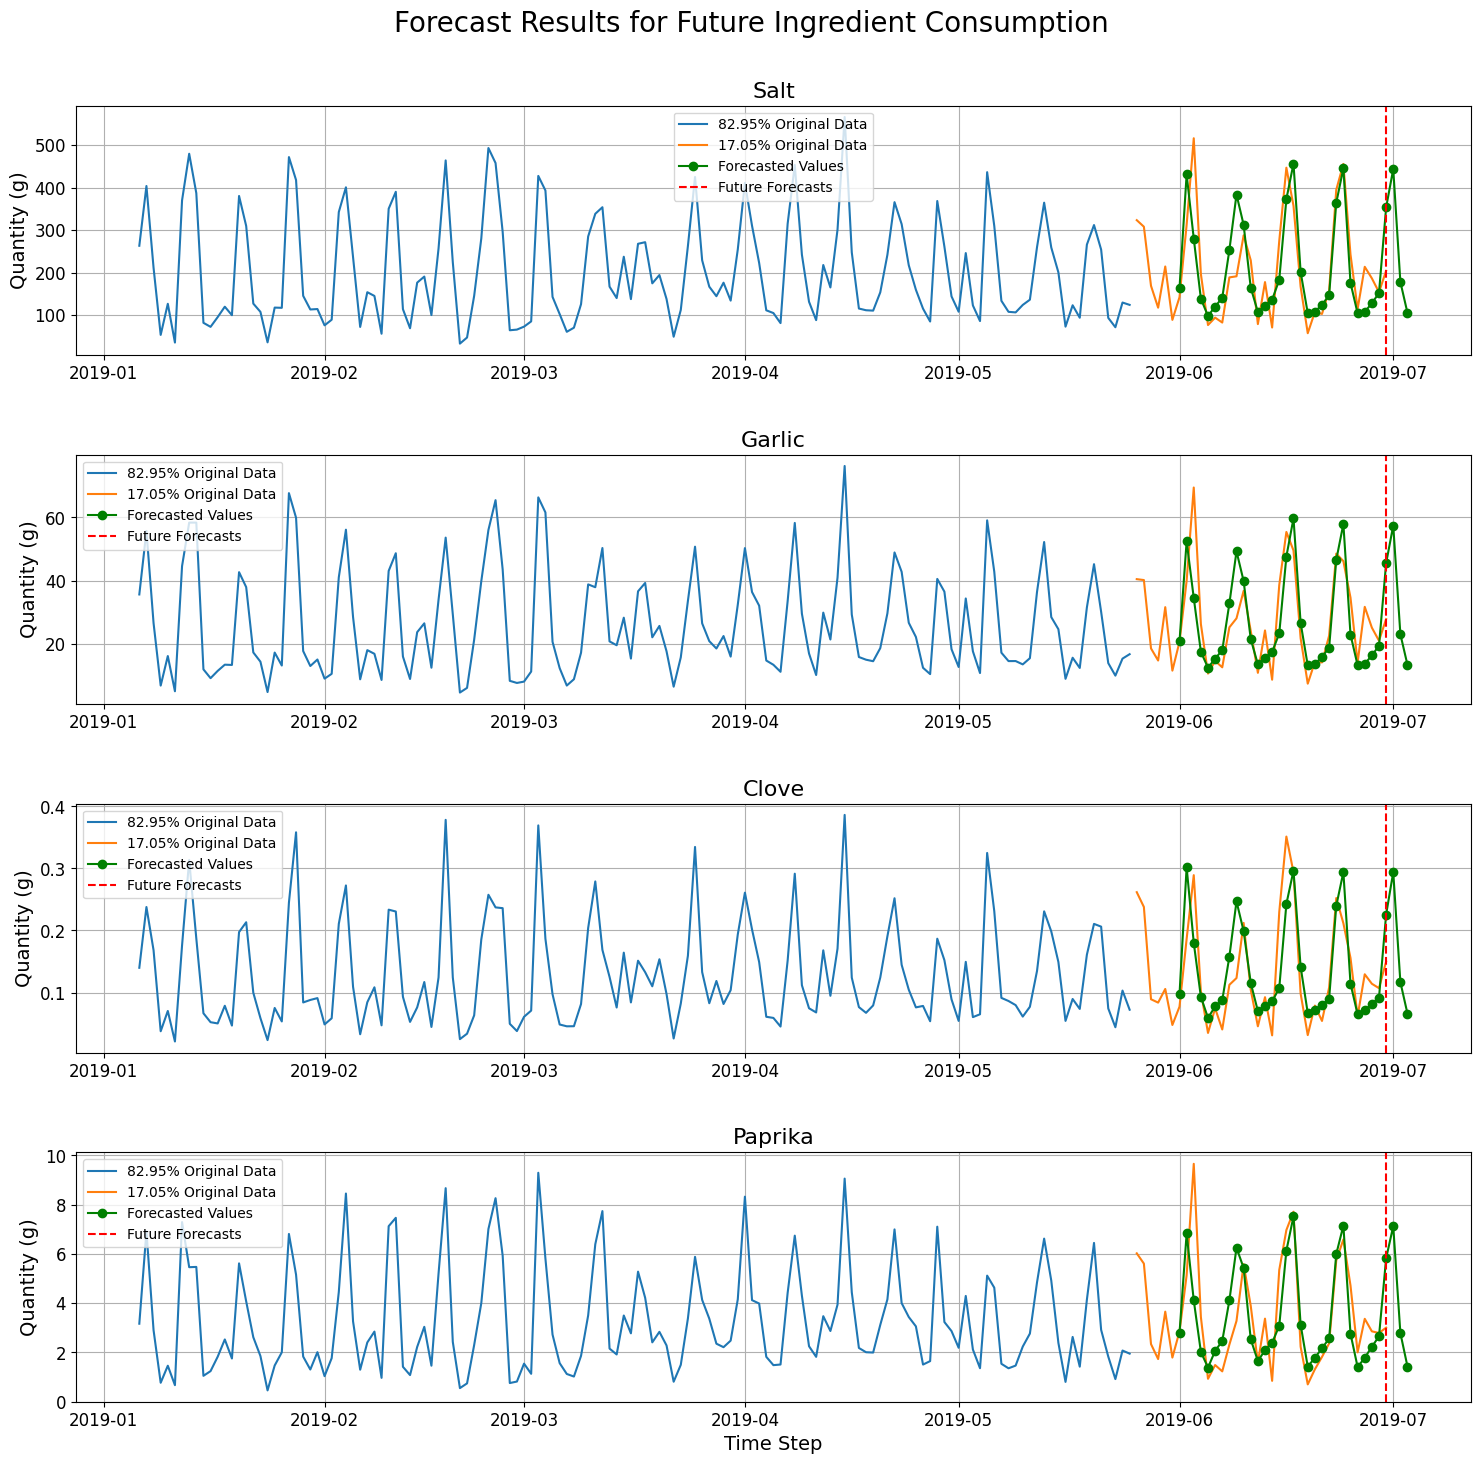

In [21]:
def plot_ingredient_forecasts(ingredients, original_time_steps, real_quantities, forecast_time_steps, forecast_values):

    num_ingredients = len(ingredients)
    fig, axes = plt.subplots(num_ingredients, 1, figsize=(18, 4 * num_ingredients))

    # If there's only one ingredient, make axes iterable
    if num_ingredients == 1:
        axes = [axes]

    for i, ingr in enumerate(ingredients):
        ax = axes[i]
        
        # Determine the split index for training and testing data - Holdout cross-validation
        split_index = int(len(original_time_steps) * 0.80) 
        print("split_index: ", split_index)

        # Plot the original/train quantities until the predicted date
        ax.plot(original_time_steps[:split_index], real_quantities[i][:split_index], label="82.95% Original Data") 

        # The historical data used as input for forecasting - all test data
        ax.plot(original_time_steps[split_index:], real_quantities[i][split_index:], label="17.05% Original Data") 

        # Plot the forecasted values
        ax.plot(forecast_time_steps, forecast_values[i], label='Forecasted Values', color='green', marker='o')

        limit_time_step = pd.to_datetime("2019-06-30")

        # Find the index of June 30th in original_time_steps
        if limit_time_step in original_time_steps:
            june_30_time_step_idx = original_time_steps.get_loc(limit_time_step)
            ax.axvline(x=original_time_steps[june_30_time_step_idx], color='red', linestyle='--', label='Future Forecasts')

        # Customizing y labels, title, and grid
        ax.set_ylabel('Quantity (g)', fontsize=14)
        ax.set_title(f'{ingr}', fontsize=16)
        ax.legend()
        ax.grid(True)

        # Increase the font size for the ticks
        ax.tick_params(axis='both', which='major', labelsize=12)

        # Only set the x-label for the last plot
        if i == num_ingredients - 1:
            ax.set_xlabel('Time Step', fontsize=14)

    # Set the global figure title and subtitle
    fig.suptitle('Forecast Results for Future Ingredient Consumption', fontsize=20)

    # Adjust the spacing to reduce the gap between the subtitle and the first plot
    plt.subplots_adjust(hspace=0.4, top=0.92)  # Reduced 'top' from default (around 0.95) to 0.92
    plt.show()


future_data = []
forecasted_values_list = []
for idx, ingredient in enumerate(target_columns):
    print("(", idx," , ", ingredient,")")
    
    # Ingredient real quantities based on the right time step
    ingredient_real_quantities = daily_consumption_df[ingredient][window:]
    # Real Dates based on the right time step
    original_time_steps = daily_consumption_df.index[window:]

    forecasted_cases = scaler.inverse_transform(np.array(forecasted_values))
    ingr_forecast = forecasted_cases[:, idx].reshape(-1, 1)

    # Append forecast values to the list
    future_data.append({
        'ingredient': ingredient,
        'Date': total_forecast_dates[-num_future_steps:], # future dates
        'Forecast Quantity': ingr_forecast[-num_future_steps:].flatten() # future quantities
    })

    forecasted_values_list.append(ingr_forecast)

# Optionally plot the forecasts for all ingredients
plot_ingredient_forecasts(
    target_columns, 
    original_time_steps, 
    [daily_consumption_df[ingredient][window:] for ingredient in target_columns],  
    total_forecast_dates, 
    forecasted_values_list
)


In [22]:
# Convert list of dictionaries to a DataFrame
df = pd.DataFrame(future_data)

# Convert the DataFrame into a format suitable for pivoting
df = df.explode(['Date', 'Forecast Quantity'])

# Pivot the DataFrame to have dates as index and ingredients as columns
forecast_quantities = df.pivot(index='Date', columns='ingredient', values='Forecast Quantity')
forecast_quantities.columns.name = None

# Print or inspect the result
display(forecast_quantities)

,Clove,Garlic,Paprika,Salt
Date,,,,
2019-07-01,0.293987,57.441925,7.12634,443.773987
2019-07-02,0.116847,23.081528,2.789387,177.922775
2019-07-03,0.065823,13.339711,1.426723,104.768684


In [23]:
import json
from datetime import datetime, timedelta

# {"ingredientId": "string", "date": "2024-07-25", "quantity": 25, "measureUnit": "kg" }

# Define the ingredient IDs and measure units
ingredient_ids = {
    'Salt': '5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea',
    'Clove': 'f8989c10-b9cf-4c29-94cd-f507560f654c',
    'Paprika': '8519c9c0-19e3-4242-b161-81c7213acbae',
    'Garlic': 'eac248d0-fb9d-4263-9399-6749ebfafde3',
}

# Ensure columns are in float64 for compatibility
forecast_quantities = forecast_quantities.astype(float)
display(forecast_quantities)

# Get the current date
current_date = datetime.now()

# Update the index with current date + index position
forecast_quantities.index = [current_date + timedelta(days=i + 1) for i in range(len(forecast_quantities))]

# Convert DataFrame to list of JSON objects
json_list = []
for date, row in forecast_quantities.iterrows():
    for ingredient, quantity in row.items():
        measure_unit = 'g'  # init to grams
        final_qty = quantity  # grams
        if final_qty >= 1000:
            final_qty = round(quantity / 1000, 1)
            measure_unit = 'kg'
        else:
            final_qty = round(quantity, 0)
            if final_qty == 0:
                final_qty = round(quantity, 1)
        
        json_obj = {
            "ingredientId": ingredient_ids.get(ingredient, "unknown_id"),
            "date": date.strftime("%Y-%m-%d"),
            "quantity": final_qty,
            "measureUnit": measure_unit
        }
        json_list.append(json_obj)

# Print JSON list
print(json.dumps(json_list, indent=2))


,Clove,Garlic,Paprika,Salt
Date,,,,
2019-07-01,0.293987,57.441925,7.126340,443.773987
2019-07-02,0.116847,23.081528,2.789387,177.922775
2019-07-03,0.065823,13.339711,1.426723,104.768684


[
  {
    "ingredientId": "f8989c10-b9cf-4c29-94cd-f507560f654c",
    "date": "2024-10-07",
    "quantity": 0.3,
    "measureUnit": "g"
  },
  {
    "ingredientId": "eac248d0-fb9d-4263-9399-6749ebfafde3",
    "date": "2024-10-07",
    "quantity": 57.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "8519c9c0-19e3-4242-b161-81c7213acbae",
    "date": "2024-10-07",
    "quantity": 7.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "5ba6c6c1-d2b2-4e11-b5ab-92ecd03ba6ea",
    "date": "2024-10-07",
    "quantity": 444.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "f8989c10-b9cf-4c29-94cd-f507560f654c",
    "date": "2024-10-08",
    "quantity": 0.1,
    "measureUnit": "g"
  },
  {
    "ingredientId": "eac248d0-fb9d-4263-9399-6749ebfafde3",
    "date": "2024-10-08",
    "quantity": 23.0,
    "measureUnit": "g"
  },
  {
    "ingredientId": "8519c9c0-19e3-4242-b161-81c7213acbae",
    "date": "2024-10-08",
    "quantity": 3.0,
    "measureUnit": "g"
  },
  {
    "ingredientId

In [24]:
# Write JSON list to a file
with open('forecast_data.json', 'w') as json_file:
    json.dump(json_list, json_file, indent=2)